# YogAI — Warrior2 Pose Experiment
**Comparative ML Study: Logistic Regression vs SVC vs KNN vs XGBoost**

This notebook runs the full hyperparameter search, cross-validation, and
inference latency benchmark for the **Warrior2 Pose** classifier.

All artifacts (pipeline, label encoder, class map, metadata) are saved to
the working directory so they can be loaded directly during real-video inference.


### Notebook Structure
1. Environment setup & imports  
2. Configuration — Warrior2 Pose  
3. Data loading & validation  
4. Exploratory checks (class balance, feature stats)  
5. Experiment loop — all 4 models  
6. Results & benchmark table  
7. Artifact verification  
8. Inference smoke-test (load saved artifacts & predict one sample)


## 1. Environment Setup

In [114]:
# Install dependencies if running for the first time
# Comment out after first run
import subprocess, sys

packages = ["scikit-learn", "xgboost", "pandas", "numpy", "matplotlib",
            "seaborn", "joblib", "pyyaml"]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All dependencies ready.")

All dependencies ready.


In [115]:
import sys
import json
import time
import math
import warnings
import logging
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, GroupKFold,StratifiedGroupKFold,
    train_test_split,
)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

#  Add src/ to path so we can import project modules 
NOTEBOOK_DIR = Path(".").resolve()

# Go up from src/models/training -> project root
PROJECT_ROOT = NOTEBOOK_DIR.parents[2]

SRC_DIR = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_DIR))

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)

print(f"Working directory : {NOTEBOOK_DIR}")
print(f"src/ on path      : {SRC_DIR.exists()}")

Working directory : D:\YogAi_Models_Refactor\src\models\training
src/ on path      : True


## 2. Configuration — Warrior2 Pose

In [170]:
#  Pose identity 
POSE_NAME = "warrior2_pose"

# Path to the Warrior2 pose CSV
# Update this to your actual file path if it differs
CSV_PATH = Path("../../../data/processed/engineered_features/warrior2_pose/warrior2_pose_features.csv")


#  Feature columns (must match CSV headers exactly) 
FEATURE_COLUMNS = [
    "back_knee_flexion_angle",
    "front_knee_flexion_angle",
    # "front_arm_torso_angle",
    # "back_arm_torso_angle",
    "spine_hip_angle",

    "stance_width_normalized",
    "front_knee_ankle_alignment",
    "center_of_mass_torso_offset",
    "wrist_height_symmetry",
    "front_wrist_shoulder_vertical_offset",
    "back_wrist_shoulder_vertical_offset"
]

LABEL_COLUMN    = "label"
SOURCE_ID_COL   = "source_id"        # same value for all frames from one video
FRAME_NUMBER_COL = "frame_number"

#  Cross-validation settings 
CV_CONFIG = {
    # "n_splits"   : 5,
    "n_splits"   : 2,
    "random_seed": 42,
    "scoring"    : "f1_weighted",
    "n_jobs"     : -1,
}

#  Hyperparameter grids 
# KNN NOTE: n_neighbors must never exceed floor(sqrt(n_training_samples)).
# A runtime warning is raised below if any value violates this.
HYPERPARAMETER_GRIDS = {
    "logistic_regression": {
        "classifier__C"       : [0.01, 0.1, 1.0, 10.0, 100.0],
        "classifier__penalty" : ["l2"],
        "classifier__solver"  : ["lbfgs"],
        "classifier__max_iter": [1000],
    },
    "svc": {
        "classifier__C"     : [0.1, 1.0, 10.0, 100.0],
        "classifier__kernel": ["rbf", "linear"],
        "classifier__gamma" : ["scale", "auto"],
    },
    "knn": {
        "classifier__n_neighbors": [3, 5, 7, 11, 15],
        "classifier__weights"    : ["uniform", "distance"],
        "classifier__metric"     : ["euclidean", "manhattan"],
    },
    "xgboost": {
        "classifier__n_estimators"    : [100, 200, 300],
        "classifier__max_depth"       : [3, 5, 7],
        "classifier__learning_rate"   : [0.01, 0.05, 0.1, 0.2],
        "classifier__subsample"       : [0.7, 0.8, 1.0],
        "classifier__colsample_bytree": [0.7, 0.8, 1.0],
        "classifier__min_child_weight": [1, 3, 5],
    },
}

XGBOOST_RANDOM_SEARCH_ITER = 30
LATENCY_WARMUP_CALLS       = 10
LATENCY_TRIAL_CALLS        = 500

print("Configuration loaded.")
print(f"Pose            : {POSE_NAME}")
print(f"Features        : {FEATURE_COLUMNS}")
print(f"CSV path        : {CSV_PATH}")
print(f"CSV exists      : {CSV_PATH.exists()}")

Configuration loaded.
Pose            : warrior2_pose
Features        : ['back_knee_flexion_angle', 'front_knee_flexion_angle', 'spine_hip_angle', 'stance_width_normalized', 'front_knee_ankle_alignment', 'center_of_mass_torso_offset', 'wrist_height_symmetry', 'front_wrist_shoulder_vertical_offset', 'back_wrist_shoulder_vertical_offset']
CSV path        : ..\..\..\data\processed\engineered_features\warrior2_pose\warrior2_pose_features.csv
CSV exists      : True


In [171]:
#  Output folder structure 
# Root is created one level above the notebook file (.. folder)
# Structure:
#   ../Warrior2_pose_files/
#       models/       — .joblib pipeline and label encoder files
#       metadata/     — .json class maps and metadata files
#       results/      — experiment summary CSV
#       images/       — confusion matrix and latency chart PNGs

NOTEBOOK_DIR  = Path(".").resolve()
OUTPUT_ROOT = NOTEBOOK_DIR.parent / "saved_files" / f"{POSE_NAME}_files"

DIR_MODELS    = OUTPUT_ROOT / "models"
DIR_METADATA  = OUTPUT_ROOT / "metadata"
DIR_RESULTS   = OUTPUT_ROOT / "results"
DIR_IMAGES    = OUTPUT_ROOT / "images"

for folder in [DIR_MODELS, DIR_METADATA, DIR_RESULTS, DIR_IMAGES]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Output root : {OUTPUT_ROOT}")
print(f"  models/   : {DIR_MODELS}")
print(f"  metadata/ : {DIR_METADATA}")
print(f"  results/  : {DIR_RESULTS}")
print(f"  images/   : {DIR_IMAGES}")

Output root : D:\YogAi_Models_Refactor\src\models\saved_files\warrior2_pose_files
  models/   : D:\YogAi_Models_Refactor\src\models\saved_files\warrior2_pose_files\models
  metadata/ : D:\YogAi_Models_Refactor\src\models\saved_files\warrior2_pose_files\metadata
  results/  : D:\YogAi_Models_Refactor\src\models\saved_files\warrior2_pose_files\results
  images/   : D:\YogAi_Models_Refactor\src\models\saved_files\warrior2_pose_files\images


## 3. Data Loading & Validation

In [172]:
#  Load CSV 
assert CSV_PATH.exists(), (
    f"CSV not found at '{CSV_PATH}'. "
    f"Update CSV_PATH in the Configuration cell above."
)

df = pd.read_csv(CSV_PATH)
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (5372, 12)


,source_id,label,frame_number,back_knee_flexion_angle,front_knee_flexion_angle,spine_hip_angle,stance_width_normalized,front_knee_ankle_alignment,center_of_mass_torso_offset,wrist_height_symmetry,front_wrist_shoulder_vertical_offset,back_wrist_shoulder_vertical_offset
0,back_leg_bent-3.mp4,back_leg_bent,8,141.098805,123.077615,106.112364,2.378752,0.198858,0.055733,0.620294,0.032724,0.642898
1,back_leg_bent-3.mp4,back_leg_bent,16,141.870123,123.926665,104.721643,2.338755,0.200634,0.068248,0.609589,0.030487,0.628011
2,back_leg_bent-3.mp4,back_leg_bent,24,143.763283,123.982365,106.447600,2.378136,0.198045,0.117325,0.565476,0.019173,0.577892
3,back_leg_bent-3.mp4,back_leg_bent,32,143.009513,123.259346,105.564349,2.345955,0.196496,0.148049,0.591119,0.014085,0.607671
4,back_leg_bent-3.mp4,back_leg_bent,40,144.298127,122.597744,102.289231,2.394251,0.206257,0.161446,0.749501,0.107230,0.644570


In [173]:
#  Validate required columns are present 
required_cols = FEATURE_COLUMNS + [LABEL_COLUMN, SOURCE_ID_COL]
missing_cols  = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(
        f"The following required columns are missing from the CSV: {missing_cols}\n"
        f"Available columns: {list(df.columns)}"
    )

print("All required columns present.")
print(f"\nColumn dtypes:")
print(df[required_cols].dtypes)

All required columns present.

Column dtypes:
back_knee_flexion_angle                 float64
front_knee_flexion_angle                float64
spine_hip_angle                         float64
stance_width_normalized                 float64
front_knee_ankle_alignment              float64
center_of_mass_torso_offset             float64
wrist_height_symmetry                   float64
front_wrist_shoulder_vertical_offset    float64
back_wrist_shoulder_vertical_offset     float64
label                                       str
source_id                                   str
dtype: object


In [174]:
#  Check for nulls 
null_counts = df[required_cols].isnull().sum()
null_counts = null_counts[null_counts > 0]

if not null_counts.empty:
    print("WARNING: Null values detected:")
    print(null_counts)
    print("\nDropping rows with nulls...")
    df = df.dropna(subset=required_cols)
    print(f"Shape after dropping nulls: {df.shape}")
else:
    print("No null values. Dataset is clean.")

No null values. Dataset is clean.


In [175]:
#  Encode string labels to integers 
# LabelEncoder is fitted here on the full label set so all classes are known.
# The fitted encoder is saved as an artifact — inference must load and use
# this exact encoder to decode predictions back to strings.

label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(df[LABEL_COLUMN].str.lower().str.strip())

class_map = {idx: cls for idx, cls in enumerate(label_encoder.classes_)}
print("Label encoding:")
for k, v in class_map.items():
    count = (y_encoded == k).sum()
    print(f"  {k} -> '{v}'  ({count} samples, {count/len(y_encoded)*100:.1f}%)")

Label encoding:
  0 -> 'back_leg_bent'  (900 samples, 16.8%)
  1 -> 'correct'  (873 samples, 16.3%)
  2 -> 'drooping_arms'  (900 samples, 16.8%)
  3 -> 'knee_caved'  (900 samples, 16.8%)
  4 -> 'leaning_torso'  (899 samples, 16.7%)
  5 -> 'shallow_stance'  (900 samples, 16.8%)


**Label encoding**:
  - 0 -> 'arms_not_dropped'  (900 samples, 19.4%)
  - 1 -> 'bent_forward'  (900 samples, 19.4%)
  - 2 -> 'correct'  (1040 samples, 22.4%)
  - 3 -> 'tilted_head'  (900 samples, 19.4%)
  - 4 -> 'wide_stance'  (900 samples, 19.4%)

In [176]:
#  Extract X, y, groups 
X      = df[FEATURE_COLUMNS].values
y      = y_encoded
groups = df[SOURCE_ID_COL].values   # one group = one video source

n_unique_sources = len(np.unique(groups))
n_samples        = len(X)

print(f"\nDataset summary")
print(f"  Samples         : {n_samples}")
print(f"  Features        : {X.shape[1]}")
print(f"  Classes         : {len(class_map)}")
print(f"  Unique source_ids: {n_unique_sources}")
print(f"  (each source_id will stay entirely in train OR test — never split across both)")


Dataset summary
  Samples         : 5372
  Features        : 9
  Classes         : 6
  Unique source_ids: 313
  (each source_id will stay entirely in train OR test — never split across both)


In [177]:
#  Experiment toggle — exclude bent_forward ─
# HYPOTHESIS: bent_forward and correct share overlapping feature distributions,
# causing the model to conflate the two classes. This experiment tests whether
# removing bent_forward improves correct's recall and overall model performance.
#
# Set to True to run the 4-class experiment (excluding bent_forward)
# Set to False to run the full 5-class experiment (default)

EXCLUDE_BENT_FORWARD = False   # <-- toggle here

#  Apply filter ─
if EXCLUDE_BENT_FORWARD:
    bent_forward_encoded = label_encoder.transform(["shallow_stance"])[0]
    keep_mask = y != bent_forward_encoded

    X      = X[keep_mask]
    y      = y[keep_mask]
    groups = groups[keep_mask]

    # Re-encode labels to consecutive integers (0,1,2,3) after dropping a class
    # — this prevents XGBoost from seeing a gap in class indices (0,1,3,4)
    # which would cause silent errors in num_class detection
    remaining_classes  = sorted(np.unique(y))
    remap              = {old: new for new, old in enumerate(remaining_classes)}
    y                  = np.array([remap[lbl] for lbl in y])

    # Rebuild class_map and refit label_encoder on remaining classes only
    remaining_names    = label_encoder.inverse_transform(remaining_classes)
    label_encoder      = LabelEncoder()
    label_encoder.fit(remaining_names)
    class_map          = {i: name for i, name in enumerate(remaining_names)}

    experiment_tag = "reduced_class"
    print("EXCLUDED: ")
else:
    experiment_tag = "class_full"
    print("Running full class experiment.")

print(f"\nExperiment tag : {experiment_tag}")
print(f"Remaining classes ({len(class_map)}):")
for k, v in class_map.items():
    count = (y == k).sum()
    print(f"  {k} -> '{v}'  ({count} samples)")

Running full class experiment.

Experiment tag : class_full
Remaining classes (6):
  0 -> 'back_leg_bent'  (900 samples)
  1 -> 'correct'  (873 samples)
  2 -> 'drooping_arms'  (900 samples)
  3 -> 'knee_caved'  (900 samples)
  4 -> 'leaning_torso'  (899 samples)
  5 -> 'shallow_stance'  (900 samples)


## 4. Exploratory Checks

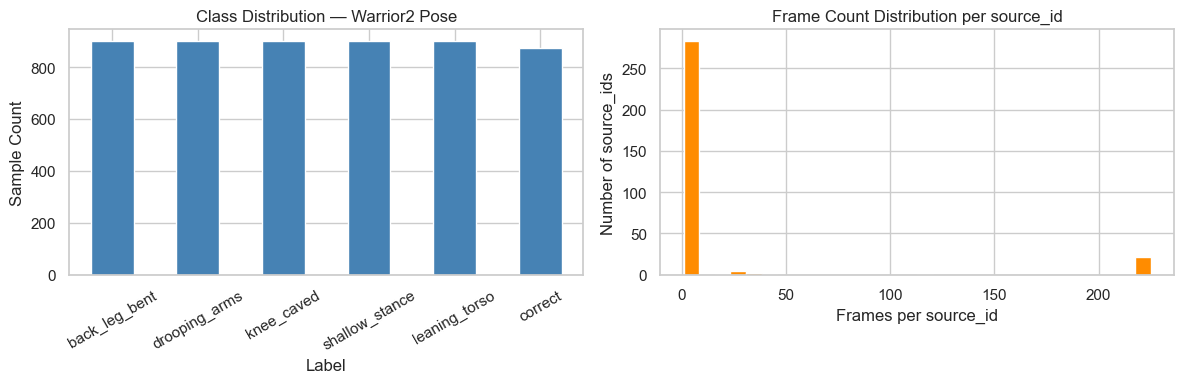

In [178]:
#  Class distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_strings = label_encoder.inverse_transform(y)
pd.Series(label_strings).value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Class Distribution — Warrior2 Pose")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Sample Count")
axes[0].tick_params(axis="x", rotation=30)

# Samples per source_id (frame count per video)
pd.Series(groups).value_counts().plot(
    kind="hist", bins=30, ax=axes[1], color="darkorange", edgecolor="white"
)
axes[1].set_title("Frame Count Distribution per source_id")
axes[1].set_xlabel("Frames per source_id")
axes[1].set_ylabel("Number of source_ids")

plt.tight_layout()
plt.show()

In [179]:
#  Feature statistics 
feature_df = pd.DataFrame(X, columns=FEATURE_COLUMNS)
feature_df.describe().round(4)

,back_knee_flexion_angle,front_knee_flexion_angle,spine_hip_angle,stance_width_normalized,front_knee_ankle_alignment,center_of_mass_torso_offset,wrist_height_symmetry,front_wrist_shoulder_vertical_offset,back_wrist_shoulder_vertical_offset
count,5372.0000,5372.0000,5372.0000,5372.0000,5372.0000,5372.0000,5372.0000,5372.0000,5372.0000
mean,171.4422,137.8155,103.6324,2.5523,0.1410,0.1525,0.2756,0.3473,0.4658
std,11.7026,19.0354,7.0271,1.5884,0.5322,0.1831,0.2740,0.5520,0.5946
min,17.2204,53.3611,48.0712,0.5037,0.0000,0.0000,0.0000,0.0000,0.0001
25%,171.7089,125.5373,100.3326,2.1913,0.0578,0.0384,0.1034,0.0944,0.1993
50%,175.1728,134.6000,103.8385,2.4123,0.1088,0.0834,0.2104,0.2309,0.3848
75%,177.6697,153.0749,107.7402,2.6915,0.1814,0.1783,0.3571,0.4877,0.5991
max,179.6068,179.5572,137.4847,111.4808,37.9482,3.7744,3.3088,32.5354,35.3047


In [180]:
# Count before filtering
initial_count = len(feature_df)

# Apply the outlier filter
feature_df = feature_df[feature_df['stance_width_normalized'] < 5.0]

# Count after filtering
final_count = len(feature_df)
dropped_count = initial_count - final_count

# Print the breakdown nicely
print(f"--- Stance Width Outlier Removal Summary ---")
print(f"Initial row count: {initial_count}")
print(f"Rows dropped (stance width >= 5.0): {dropped_count}")
print(f"Final cleaned row count: {final_count}")
print(f"--------------------------------------------")

--- Stance Width Outlier Removal Summary ---
Initial row count: 5372
Rows dropped (stance width >= 5.0): 14
Final cleaned row count: 5358
--------------------------------------------


In [181]:
# Drop rows where normalized stance width is unrealistically high (e.g., > 5.0)
feature_df = feature_df[feature_df['stance_width_normalized'] < 5.0]

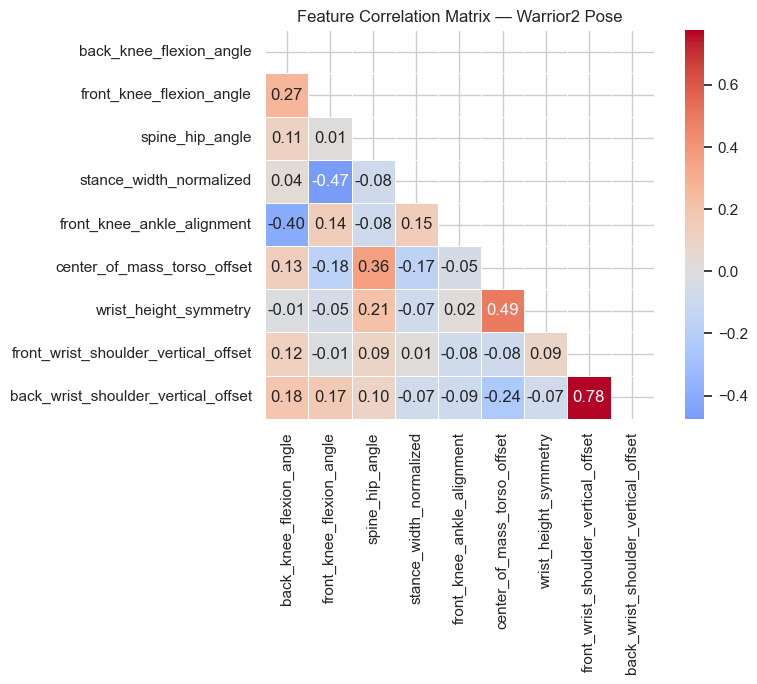

In [182]:
#  Feature correlation heatmap 
fig, ax = plt.subplots(figsize=(9, 7))
corr = feature_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, ax=ax,
    linewidths=0.5, square=True,
)
ax.set_title("Feature Correlation Matrix — Warrior2 Pose")
plt.tight_layout()
plt.show()

## 5. Experiment Helpers

In [183]:
def build_pipeline(model_name: str) -> Pipeline:
    """
    Return an unfitted sklearn Pipeline: StandardScaler -> estimator.
    Must be unfitted when passed to GridSearchCV to prevent leakage.
    """
    seed = CV_CONFIG["random_seed"]

    estimators = {
        "logistic_regression": LogisticRegression(random_state=seed, max_iter=1000),
        "svc"                : SVC(random_state=seed, probability=True),
        "knn"                : KNeighborsClassifier(n_neighbors=5),
        "xgboost"            : XGBClassifier(
                                   random_state=seed,
                                   verbosity=0,
                                   eval_metric="mlogloss",
                               ),
    }

    if model_name not in estimators:
        raise ValueError(f"Unknown model '{model_name}'. Choose from {list(estimators)}")

    return Pipeline([
        ("scaler"    , StandardScaler()),
        ("classifier", estimators[model_name]),
    ])


def check_knn_neighbor_cap(n_neighbors_grid: list, n_training_samples: int) -> None:
    """Warn if any n_neighbors value exceeds floor(sqrt(n_training_samples))."""
    ceiling    = math.floor(math.sqrt(n_training_samples))
    oversized  = [k for k in n_neighbors_grid if k > ceiling]
    if oversized:
        warnings.warn(
            f"KNN grid has n_neighbors values {oversized} exceeding the "
            f"recommended ceiling floor(sqrt({n_training_samples})) = {ceiling}. "
            f"Consider trimming the grid.",
            UserWarning, stacklevel=2,
        )


def measure_inference_latency(
    pipeline, X_probe: np.ndarray,
    n_warmup: int = LATENCY_WARMUP_CALLS,
    n_trials: int = LATENCY_TRIAL_CALLS,
) -> dict:
    """
    Measure per-sample prediction latency.
    Warm-up calls are discarded to eliminate cold-start bias.
    p95/p99 are reported because real-time systems are bounded by tail latency.
    """
    for _ in range(n_warmup):
        pipeline.predict(X_probe)

    latencies_ms = np.empty(n_trials)
    for i in range(n_trials):
        t0 = time.perf_counter()
        pipeline.predict(X_probe)
        latencies_ms[i] = (time.perf_counter() - t0) * 1000.0

    return {
        "mean_ms"        : round(float(np.mean(latencies_ms)), 4),
        "std_ms"         : round(float(np.std(latencies_ms)), 4),
        "p95_ms"         : round(float(np.percentile(latencies_ms, 95)), 4),
        "p99_ms"         : round(float(np.percentile(latencies_ms, 99)), 4),
        "implied_max_fps": round(1000.0 / float(np.mean(latencies_ms)), 1),
    }

def load_results_from_disk(pose_name: str, experiment_tag: str, 
                            models: list, DIR_METADATA: Path) -> list:
    """
    Load experiment results from saved metadata JSONs.
    Use this to restore any experiment without re-running.
    """
    results = []
    
    for model_name in models:
        prefix    = f"{pose_name}_{experiment_tag}_{model_name}"
        meta_path = DIR_METADATA / f"{prefix}_metadata.json"
        
        if not meta_path.exists():
            print(f"[WARNING] Missing: {meta_path.name} — skipping")
            continue
            
        with open(meta_path) as f:
            results.append(json.load(f))
            
    print(f"Loaded {len(results)}/{len(models)} models "
          f"for '{pose_name}' — '{experiment_tag}'")
    return results


# Usage — load any experiment by just changing the tag
# all_results_4class = load_results_from_disk(
#     pose_name      = POSE_NAME,
#     experiment_tag = "4class_no_bent_forward",
#     models         = ["logistic_regression", "svc", "knn", "xgboost"],
#     DIR_METADATA   = DIR_METADATA,
# )

# After 5-class run, load that too the same way
# all_results_5class = load_results_from_disk(
#     pose_name      = POSE_NAME,
#     experiment_tag = "5class_full",
#     models         = ["logistic_regression", "svc", "knn", "xgboost"],
#     DIR_METADATA   = DIR_METADATA,
# )

print("Helper functions defined.")

Helper functions defined.


## 6. Train / Test Split

In [184]:
from collections import defaultdict
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

# 1. Initialize Seed
seed = CV_CONFIG["random_seed"]
rng  = np.random.default_rng(seed)

# 2. Build a map: source_id -> majority class label 
# (Each video/source_id maps to its primary class label to handle minor frame noise)
source_to_label = {}
for src in np.unique(groups):
    mask = groups == src
    majority_label = int(pd.Series(y[mask]).mode()[0])
    source_to_label[src] = majority_label

# 3. Group source_ids by their class for descriptive logging
class_to_sources = defaultdict(list)
for src, lbl in source_to_label.items():
    class_to_sources[lbl].append(src)

print("Source_ids per class:")
for lbl, srcs in sorted(class_to_sources.items()):
    print(f"  {class_map[lbl]}: {len(srcs)} source_ids")

# 4. Stratified Group-Aware Train/Test Split
# We use 5 splits (1/5 = 20%) to pull out a perfectly stratified, leak-free test track
outer_cv = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=seed)

# Extract the indices for the first fold split
train_idx, test_idx = next(outer_cv.split(X, y, groups=groups))

# 5. Create clean, leak-free, class-balanced matrices
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train    = groups[train_idx]

# Extract distinct video paths/IDs for log tracking tracking
train_sources = set(np.unique(groups_train))
test_sources  = set(np.unique(groups[test_idx]))

# 6. Verify and Print Split Metadata
print(f"\nTrain: {len(X_train)} samples across {len(train_sources)} source_ids")
print(f"Test : {len(X_test)} samples across {len(test_sources)} source_ids")

print("\nTrain class distribution:")
for k, v in class_map.items():
    count = (y_train == k).sum()
    print(f"  {v}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nTest class distribution:")
for k, v in class_map.items():
    count = (y_test == k).sum()
    print(f"  {v}: {count} ({count/len(y_test)*100:.1f}%)")

Source_ids per class:
  back_leg_bent: 4 source_ids
  correct: 293 source_ids
  drooping_arms: 4 source_ids
  knee_caved: 4 source_ids
  leaning_torso: 4 source_ids
  shallow_stance: 4 source_ids

Train: 2686 samples across 150 source_ids
Test : 2686 samples across 163 source_ids

Train class distribution:
  back_leg_bent: 450 (16.8%)
  correct: 436 (16.2%)
  drooping_arms: 450 (16.8%)
  knee_caved: 450 (16.8%)
  leaning_torso: 450 (16.8%)
  shallow_stance: 450 (16.8%)

Test class distribution:
  back_leg_bent: 450 (16.8%)
  correct: 437 (16.3%)
  drooping_arms: 450 (16.8%)
  knee_caved: 450 (16.8%)
  leaning_torso: 449 (16.7%)
  shallow_stance: 450 (16.8%)


In [185]:
# from collections import defaultdict

# seed = CV_CONFIG["random_seed"]
# rng  = np.random.default_rng(seed)

# #  Build a map: source_id -> majority class label ─
# # Each source_id belongs to one class (one video = one pose correctness label)
# # We take the majority label in case of any noise/mixed frames
# source_to_label = {}
# for src in np.unique(groups):
#     mask = groups == src
#     majority_label = int(pd.Series(y[mask]).mode()[0])
#     source_to_label[src] = majority_label

# #  Group source_ids by their class ─
# class_to_sources = defaultdict(list)
# for src, lbl in source_to_label.items():
#     class_to_sources[lbl].append(src)

# print("Source_ids per class:")
# for lbl, srcs in sorted(class_to_sources.items()):
#     print(f"  {class_map[lbl]}: {len(srcs)} source_ids")

# #  Sample 20% of source_ids from EACH class for test ─
# test_sources  = set()
# train_sources = set()

# for lbl, srcs in class_to_sources.items():
#     srcs_arr       = np.array(srcs)
#     n_test         = max(1, int(len(srcs_arr) * 0.2))
#     chosen_test    = set(rng.choice(srcs_arr, size=n_test, replace=False))
#     test_sources  |= chosen_test
#     train_sources |= (set(srcs_arr) - chosen_test)

# #  Apply masks 
# test_mask  = np.isin(groups, list(test_sources))
# train_mask = ~test_mask

# X_train, X_test = X[train_mask], X[test_mask]
# y_train, y_test = y[train_mask], y[test_mask]
# groups_train    = groups[train_mask]

# print(f"\nTrain: {len(X_train)} samples across {len(train_sources)} source_ids")
# print(f"Test : {len(X_test)} samples across {len(test_sources)} source_ids")

# print("\nTrain class distribution:")
# for k, v in class_map.items():
#     count = (y_train == k).sum()
#     print(f"  {v}: {count} ({count/len(y_train)*100:.1f}%)")

# print("\nTest class distribution:")
# for k, v in class_map.items():
#     count = (y_test == k).sum()
#     print(f"  {v}: {count} ({count/len(y_test)*100:.1f}%)")

In [186]:
#  Class balance assessment ─
train_counts = pd.Series(y_train).value_counts().sort_index()
max_count    = train_counts.max()
min_count    = train_counts.min()
imbalance_ratio = max_count / min_count

print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")

if imbalance_ratio < 1.5:
    print("Assessment: BALANCED — no resampling or class weighting needed.")
    print("Justification: ratio < 1.5, f1_weighted scoring already accounts")
    print("for minor differences in class support.")
elif imbalance_ratio < 3.0:
    print("Assessment: MILDLY IMBALANCED — consider class_weight='balanced'")
    print("for LogisticRegression and SVC.")
else:
    print("Assessment: IMBALANCED — add class_weight='balanced' to LR and SVC,")
    print("and set scale_pos_weight in XGBoost.")

Imbalance ratio (max/min): 1.03
Assessment: BALANCED — no resampling or class weighting needed.
Justification: ratio < 1.5, f1_weighted scoring already accounts
for minor differences in class support.


## 7. Experiment Loop — All 4 Models

In [187]:
# Assertions before loop
assert seed is not None, "Global seed must be set before the experiment loop"

# GroupKFold — folds also respect source_id boundaries during CV
n_unique_train_sources = len(np.unique(groups_train))
n_splits_actual        = min(CV_CONFIG["n_splits"], n_unique_train_sources)
cv_strategy            = StratifiedGroupKFold(n_splits=n_splits_actual)

print(f"CV strategy : GroupKFold with {n_splits_actual} splits")
print(f"Scoring     : {CV_CONFIG['scoring']}")
print()

MODELS         = ["logistic_regression", "svc", "knn", "xgboost"]
all_results    = []
best_pipelines = {}

# Constant to avoid magic string
WEIGHTED_AVG_KEY = "weighted avg"

for model_name in MODELS:
    print(f"{'='*60}")
    print(f"  Running: {model_name.upper().replace('_', ' ')}")
    print(f"{'='*60}")

    try:
        # Build unfitted pipeline — scaler must not be fitted before GridSearchCV
        pipeline   = build_pipeline(model_name)
        param_grid = HYPERPARAMETER_GRIDS[model_name]

        # KNN neighbor cap — guard against smallest fold, not full X_train
        if model_name == "knn":
            min_fold_train_size = int(len(X_train) * (n_splits_actual - 1) / n_splits_actual)
            check_knn_neighbor_cap(
                param_grid["classifier__n_neighbors"], min_fold_train_size
            )

        # XGBoost uses RandomizedSearchCV due to larger grid
        if model_name == "xgboost":
            search = RandomizedSearchCV(
                estimator=pipeline,
                param_distributions=param_grid,
                n_iter=XGBOOST_RANDOM_SEARCH_ITER,
                scoring=CV_CONFIG["scoring"],
                cv=cv_strategy,
                n_jobs=CV_CONFIG["n_jobs"],
                random_state=seed,
                refit=True,
                verbose=0,
            )
        else:
            search = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                scoring=CV_CONFIG["scoring"],
                cv=cv_strategy,
                n_jobs=CV_CONFIG["n_jobs"],
                refit=True,
                verbose=0,
            )

        search.fit(X_train, y_train, groups=groups_train)

        best_pipeline = search.best_estimator_
        best_pipelines[model_name] = best_pipeline

        # Evaluate on held-out test set
        y_pred   = best_pipeline.predict(X_test)
        clf_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        clf_str  = classification_report(
                       y_test, y_pred,
                       target_names=list(class_map.values()),
                       zero_division=0,
                   )
        conf_mat = confusion_matrix(y_test, y_pred)

        # Inference latency — 50-sample batch for stable estimates
        X_probe = X_test[:50]
        latency = measure_inference_latency(best_pipeline, X_probe)

        # Result dictionary
        result = {
            "model"                    : model_name,
            "best_cv_score"            : round(search.best_score_, 4),
            "test_f1_weighted"         : round(clf_dict[WEIGHTED_AVG_KEY]["f1-score"], 4),
            "test_precision_weighted"  : round(clf_dict[WEIGHTED_AVG_KEY]["precision"], 4),
            "test_recall_weighted"     : round(clf_dict[WEIGHTED_AVG_KEY]["recall"], 4),
            "test_accuracy"            : round(clf_dict["accuracy"], 4),
            "best_params"              : search.best_params_,
            "classification_report_str": clf_str,
            "confusion_matrix"         : conf_mat,          # raw ndarray — available for ROC plot
            "confusion_matrix_list"    : conf_mat.tolist(), # JSON-serialisable copy
            **latency,
        }

        # Dynamic fold score extraction
        best_index = search.best_index_
        fold_scores = [
            round(search.cv_results_[f"split{i}_test_score"][best_index], 4)
            for i in range(n_splits_actual)
        ]
        result["cv_folds_scores"] = fold_scores

        # Explainable AI — feature importances
        classifier_step = best_pipeline.named_steps["classifier"]
        if model_name == "xgboost":
            result["feature_importances"]     = classifier_step.feature_importances_.tolist()
            result["has_feature_importances"] = True
        elif model_name == "logistic_regression":
            result["feature_importances"]     = np.mean(np.abs(classifier_step.coef_), axis=0).tolist()
            result["has_feature_importances"] = True
        else:
            result["feature_importances"]     = None
            result["has_feature_importances"] = False

        all_results.append(result)

        # Per-model summary
        print(f"Best CV score  : {result['best_cv_score']}")
        print(f"Best params    : {search.best_params_}")
        print()
        print("Classification Report (test set):")
        print(clf_str)
        print(f"Latency  mean={latency['mean_ms']} ms | "
              f"p95={latency['p95_ms']} ms | "
              f"p99={latency['p99_ms']} ms | "
              f"implied FPS={latency['implied_max_fps']}")

        # Save artifacts immediately after each model
        prefix = f"{POSE_NAME}_{experiment_tag}_{model_name}"

        joblib.dump(best_pipeline, DIR_MODELS / f"{prefix}_pipeline.joblib")
        joblib.dump(label_encoder, DIR_MODELS / f"{prefix}_label_encoder.joblib")

        with open(DIR_METADATA / f"{prefix}_class_map.json", "w") as f:
            json.dump({str(k): v for k, v in class_map.items()}, f, indent=2)

        metadata = {
            "pose"                 : POSE_NAME,
            "experiment_tag"       : experiment_tag,
            "model"                : model_name,
            "feature_columns"      : FEATURE_COLUMNS,
            "n_features"           : len(FEATURE_COLUMNS),
            "best_params"          : search.best_params_,
            "best_cv_score"        : result["best_cv_score"],
            "cv_folds_scores"      : fold_scores,
            "test_f1_weighted"     : result["test_f1_weighted"],
            "test_accuracy"        : result["test_accuracy"],
            "n_train"              : len(X_train),
            "n_test"               : len(X_test),
            "cv_config"            : CV_CONFIG,
            "class_map"            : {str(k): v for k, v in class_map.items()},
            "latency"              : latency,
            "confusion_matrix"     : conf_mat.tolist(), # use the serialisable copy
            "classification_report": clf_str,
        }

        with open(DIR_METADATA / f"{prefix}_metadata.json", "w") as f:
            json.dump(metadata, f, indent=2)

        print(f"Artifacts saved to {OUTPUT_ROOT.name}/")
        print(f"  models/   {prefix}_pipeline.joblib")
        print(f"  models/   {prefix}_label_encoder.joblib")
        print(f"  metadata/ {prefix}_class_map.json")
        print(f"  metadata/ {prefix}_metadata.json")
        print()

    except Exception as e:
        print(f"[ERROR] {model_name} failed — skipping. Reason: {e}")
        continue

print("All Experiments Completed.")

CV strategy : GroupKFold with 2 splits
Scoring     : f1_weighted

  Running: LOGISTIC REGRESSION
Best CV score  : 0.7627
Best params    : {'classifier__C': 1.0, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Classification Report (test set):
                precision    recall  f1-score   support

 back_leg_bent       0.91      0.90      0.90       450
       correct       0.98      0.97      0.98       437
 drooping_arms       0.94      0.87      0.91       450
    knee_caved       0.70      0.46      0.56       450
 leaning_torso       0.90      0.98      0.94       449
shallow_stance       0.56      0.75      0.64       450

      accuracy                           0.82      2686
     macro avg       0.83      0.82      0.82      2686
  weighted avg       0.83      0.82      0.82      2686

Latency  mean=0.1379 ms | p95=0.2868 ms | p99=0.4441 ms | implied FPS=7249.8


d:\YogAi_Models_Refactor\venv_yogai\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Artifacts saved to warrior2_pose_files/
  models/   warrior2_pose_class_full_logistic_regression_pipeline.joblib
  models/   warrior2_pose_class_full_logistic_regression_label_encoder.joblib
  metadata/ warrior2_pose_class_full_logistic_regression_class_map.json
  metadata/ warrior2_pose_class_full_logistic_regression_metadata.json

  Running: SVC
Best CV score  : 0.792
Best params    : {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}

Classification Report (test set):
                precision    recall  f1-score   support

 back_leg_bent       0.91      0.82      0.86       450
       correct       0.98      0.95      0.97       437
 drooping_arms       0.98      0.89      0.93       450
    knee_caved       0.71      0.41      0.52       450
 leaning_torso       0.90      0.98      0.94       449
shallow_stance       0.56      0.86      0.68       450

      accuracy                           0.82      2686
     macro avg       0.84      0.82     

## 8. Results & Benchmark Table

In [188]:
#  Flat benchmark table ─
benchmark_cols = [
    "model", "best_cv_score",
    "test_f1_weighted", "test_precision_weighted",
    "test_recall_weighted", "test_accuracy",
    "mean_ms", "p95_ms", "p99_ms", "implied_max_fps",
]

results_df = pd.DataFrame(all_results)[benchmark_cols]
results_df = results_df.sort_values("test_f1_weighted", ascending=False).reset_index(drop=True)

csv_path = DIR_RESULTS / f"{POSE_NAME}_{experiment_tag}_experiment_results.csv"
results_df.to_csv(csv_path, index=False)
print(f"Results saved to {OUTPUT_ROOT.name}/results/{csv_path.name}")
print()
results_df

Results saved to warrior2_pose_files/results/warrior2_pose_class_full_experiment_results.csv



,model,best_cv_score,test_f1_weighted,test_precision_weighted,test_recall_weighted,test_accuracy,mean_ms,p95_ms,p99_ms,implied_max_fps
0,logistic_regression,0.7627,0.8194,0.8311,0.8217,0.8217,0.1379,0.2868,0.4441,7249.8
1,svc,0.7920,0.8151,0.8386,0.8183,0.8183,0.6743,1.0019,1.5506,1483.1
2,knn,0.8054,0.7950,0.8183,0.8004,0.8004,1.8831,3.7944,5.1778,531.0
3,xgboost,0.7895,0.7350,0.7442,0.7308,0.7308,1.6636,2.6208,3.5829,601.1


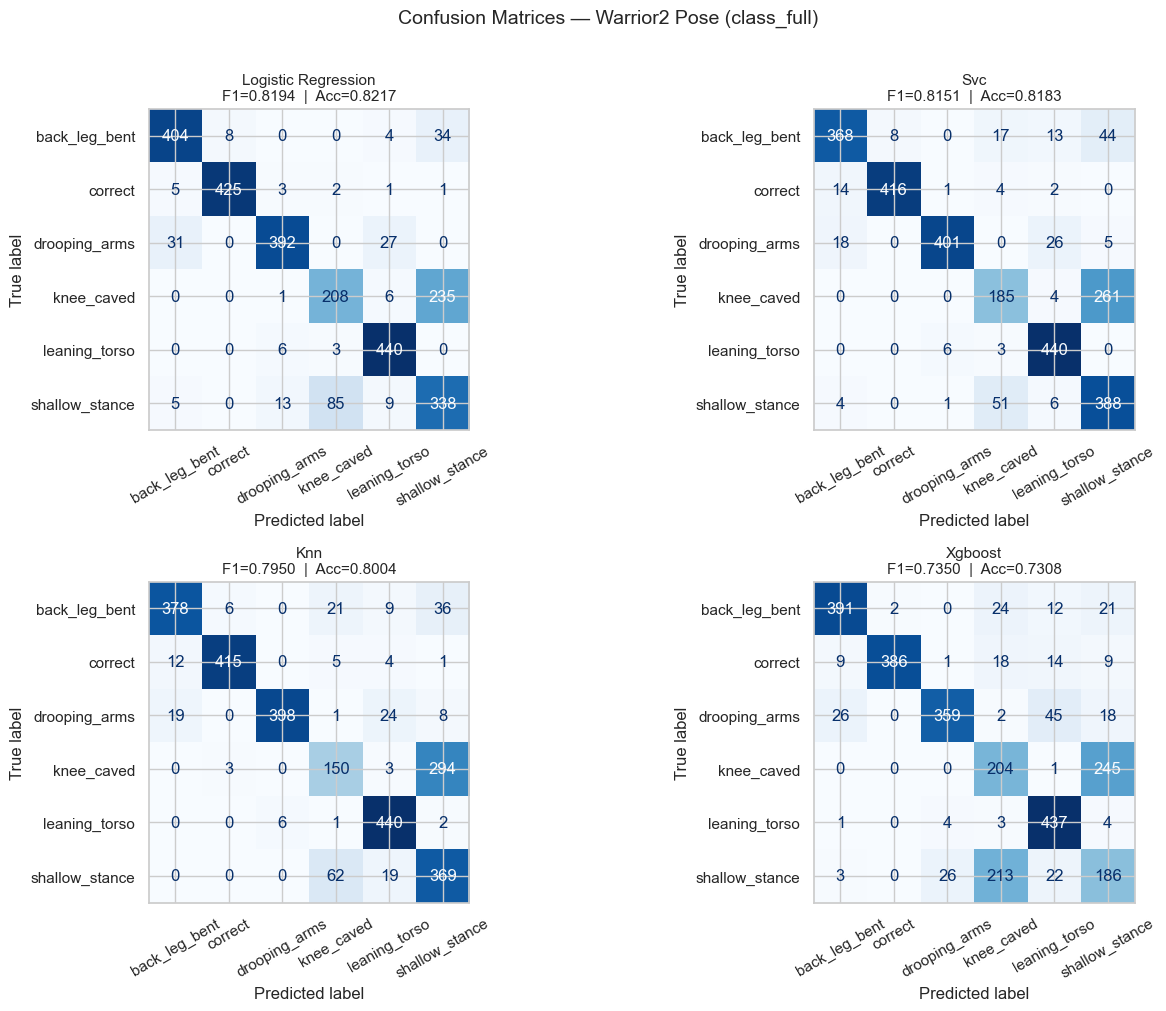

Saved -> warrior2_pose_files/images/warrior2_pose_class_full_confusion_matrices.png


In [189]:
#  Confusion matrices — all 4 models ─
fig, axes   = plt.subplots(2, 2, figsize=(14, 10))
axes        = axes.flatten()
class_names = list(class_map.values())

for i, result in enumerate(all_results):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"],
        display_labels=class_names,
    )
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(
        f"{result['model'].replace('_', ' ').title()}\n"
        f"F1={result['test_f1_weighted']:.4f}  |  "
        f"Acc={result['test_accuracy']:.4f}",
        fontsize=11,
    )
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle(
    f"Confusion Matrices — {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})",
    fontsize=14, y=1.01,
)
plt.tight_layout()

img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_confusion_matrices.png"
plt.savefig(img_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {OUTPUT_ROOT.name}/images/{img_path.name}")

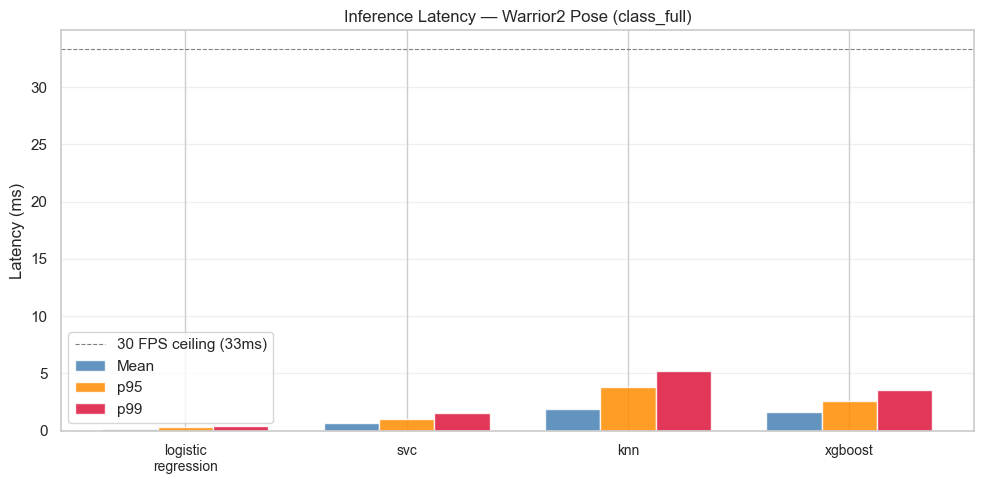

Saved -> warrior2_pose_files/images/warrior2_pose_class_full_latency_comparison.png


In [190]:
#  Latency comparison bar chart ─
fig, ax = plt.subplots(figsize=(10, 5))

model_labels = [r["model"].replace("_", "\n") for r in all_results]
mean_vals    = [r["mean_ms"] for r in all_results]
p95_vals     = [r["p95_ms"]  for r in all_results]
p99_vals     = [r["p99_ms"]  for r in all_results]

x     = np.arange(len(model_labels))
width = 0.25

ax.bar(x - width, mean_vals, width, label="Mean", color="steelblue",  alpha=0.85)
ax.bar(x,         p95_vals,  width, label="p95",  color="darkorange", alpha=0.85)
ax.bar(x + width, p99_vals,  width, label="p99",  color="crimson",    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel("Latency (ms)")
ax.set_title(
    f"Inference Latency — {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})"
)
ax.axhline(y=33.3, color="gray", linestyle="--", linewidth=0.8, label="30 FPS ceiling (33ms)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_latency_comparison.png"
plt.savefig(img_path, dpi=150)
plt.show()
print(f"Saved -> {OUTPUT_ROOT.name}/images/{img_path.name}")

## GroupKFold Stability Distribution Visual

C:\Users\Acer\AppData\Local\Temp\ipykernel_11920\2232757363.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


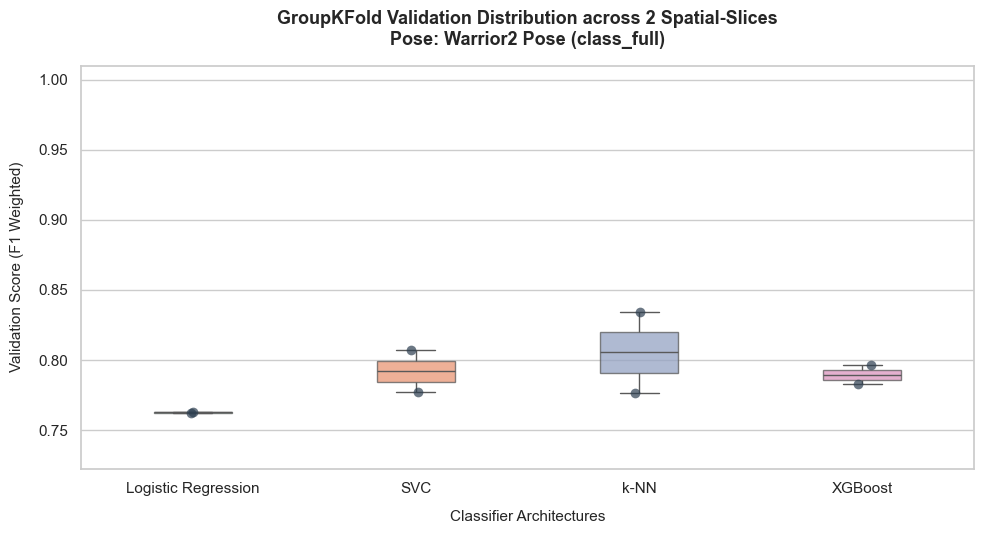

Saved publication-grade plot to: warrior2_pose_files/images/warrior2_pose_class_full_groupkfold_variance.png


In [196]:

# Structure raw data into a DataFrame
cv_box_data = {r["model"]: r["cv_folds_scores"] for r in all_results}
df_cv_box = pd.DataFrame(cv_box_data)

# Map snake_case model names to formal academic typography
formal_names = {
    "logistic_regression": "Logistic Regression",
    "svc": "SVC",
    "knn": "k-NN",
    "xgboost": "XGBoost"
}
df_cv_box.columns = [formal_names.get(col, col) for col in df_cv_box.columns]

# Melt data for Seaborn processing
df_cv_melted = df_cv_box.melt(var_name='Model', value_name='Cross-Val Score')

# Setup visualization canvas
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.set_theme(style="whitegrid")

# Draw boxes — showfliers=False removes duplicate outlier circles
sns.boxplot(
    data=df_cv_melted, 
    x='Model', 
    y='Cross-Val Score', 
    palette='Set2', 
    width=0.35, 
    showfliers=False,
    ax=ax,
    boxprops=dict(alpha=0.75)
)

# Overlay individual fold markers transparently
sns.stripplot(
    data=df_cv_melted, 
    x='Model', 
    y='Cross-Val Score', 
    color='#2c3e50', 
    alpha=0.7, 
    size=7, 
    jitter=0.05, 
    ax=ax
)

# Academic formatting and labeling adjustments
scoring_name = CV_CONFIG['scoring'].replace('_', ' ').title()
ax.set_title(
    f"GroupKFold Validation Distribution across {n_splits_actual} Spatial-Slices\n"
    f"Pose: {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})", 
    fontsize=13, 
    pad=15, 
    weight='bold'
)
ax.set_ylabel(f"Validation Score ({scoring_name})", fontsize=11, labelpad=10)
ax.set_xlabel("Classifier Architectures", fontsize=11, labelpad=10)

# Zoom in vertically to match your data range seamlessly
min_val = df_cv_melted['Cross-Val Score'].min()
ax.set_ylim(max(0.0, min_val - 0.04), 1.01)

plt.tight_layout()

# Save publication-quality artifact (300 DPI is standard for print layout)
box_img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_groupkfold_variance.png"
plt.savefig(box_img_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved publication-grade plot to: {OUTPUT_ROOT.name}/images/{box_img_path.name}")

## Diagnostic

In [192]:
# Diagnostic 
from sklearn.model_selection import StratifiedGroupKFold
import pandas as pd

sgkf = StratifiedGroupKFold(n_splits=n_splits_actual)

print(f"Total train samples : {len(X_train)}")
print(f"Unique source_ids   : {len(np.unique(groups_train))}")
print()

fold_diagnostics = []

for fold_idx, (tr_idx, val_idx) in enumerate(sgkf.split(X_train, y_train, groups=groups_train)):
    val_labels        = y_train[val_idx]
    val_sources       = groups_train[val_idx]
    
    class_counts      = {class_map[k]: int((val_labels == k).sum()) for k in sorted(class_map)}
    n_val_sources     = len(np.unique(val_sources))
    smallest_class    = min(class_counts.values())
    
    fold_diagnostics.append({
        "fold"          : fold_idx,
        "val_samples"   : len(val_idx),
        "val_sources"   : n_val_sources,
        "smallest_class": smallest_class,
        **class_counts,
    })
    
    print(f"Fold {fold_idx}  |  val_samples={len(val_idx)}  |  val_sources={n_val_sources}")
    for cls, cnt in class_counts.items():
        print(f"         {cls:<22}: {cnt}")
    print()

df_folds = pd.DataFrame(fold_diagnostics)
print("Summary:")
print(df_folds)

Total train samples : 2686
Unique source_ids   : 150

Fold 0  |  val_samples=1343  |  val_sources=65
         back_leg_bent         : 225
         correct               : 218
         drooping_arms         : 225
         knee_caved            : 225
         leaning_torso         : 225
         shallow_stance        : 225

Fold 1  |  val_samples=1343  |  val_sources=85
         back_leg_bent         : 225
         correct               : 218
         drooping_arms         : 225
         knee_caved            : 225
         leaning_torso         : 225
         shallow_stance        : 225

Summary:
   fold  val_samples  val_sources  smallest_class  back_leg_bent  correct  \
0     0         1343           65             218            225      218   
1     1         1343           85             218            225      218   

   drooping_arms  knee_caved  leaning_torso  shallow_stance  
0            225         225            225             225  
1            225         225            2

In [197]:
for n_splits in [2, 3]:
    print(f"\n{'='*40}")
    print(f"Testing n_splits = {n_splits}")
    print(f"{'='*40}")
    
    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    clean = True
    
    for fold_idx, (tr_idx, val_idx) in enumerate(sgkf.split(X_train, y_train, groups=groups_train)):
        val_labels   = y_train[val_idx]
        class_counts = {class_map[k]: int((val_labels == k).sum()) for k in sorted(class_map)}
        zeros        = [cls for cls, cnt in class_counts.items() if cnt == 0]
        
        status = "✓" if not zeros else f"✗  ZERO: {zeros}"
        print(f"  Fold {fold_idx}: {class_counts}  {status}")
        
        if zeros:
            clean = False
    
    print(f"  → {'CLEAN — safe to use' if clean else 'HAS EMPTY FOLDS — do not use'}")


Testing n_splits = 2
  Fold 0: {'back_leg_bent': 225, 'correct': 218, 'drooping_arms': 225, 'knee_caved': 225, 'leaning_torso': 225, 'shallow_stance': 225}  ✓
  Fold 1: {'back_leg_bent': 225, 'correct': 218, 'drooping_arms': 225, 'knee_caved': 225, 'leaning_torso': 225, 'shallow_stance': 225}  ✓
  → CLEAN — safe to use

Testing n_splits = 3
  Fold 0: {'back_leg_bent': 225, 'correct': 145, 'drooping_arms': 225, 'knee_caved': 0, 'leaning_torso': 225, 'shallow_stance': 225}  ✗  ZERO: ['knee_caved']
  Fold 1: {'back_leg_bent': 225, 'correct': 146, 'drooping_arms': 0, 'knee_caved': 225, 'leaning_torso': 225, 'shallow_stance': 0}  ✗  ZERO: ['drooping_arms', 'shallow_stance']
  Fold 2: {'back_leg_bent': 0, 'correct': 145, 'drooping_arms': 225, 'knee_caved': 225, 'leaning_torso': 0, 'shallow_stance': 225}  ✗  ZERO: ['back_leg_bent', 'leaning_torso']
  → HAS EMPTY FOLDS — do not use


## Global Structural Feature Importance Chart

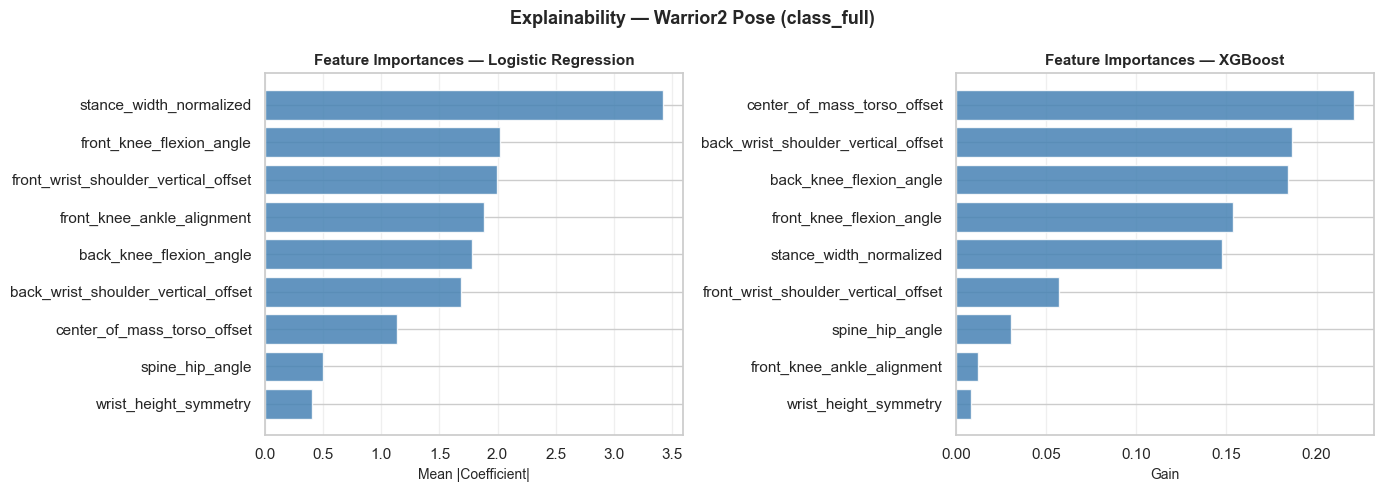

In [194]:
# # Pull out XGBoost or Logistic Regression profile results for explainable AI metrics
# xgb_res = next((item for item in all_results if item["model"] == "xgboost"), None)

# if xgb_res and xgb_res.get("feature_importances") is not None:
#     df_feat = pd.DataFrame({
#         "Feature": FEATURE_COLUMNS,
#         "Relative Importance": xgb_res["feature_importances"]
#     }).sort_values("Relative Importance", ascending=False).head(15) # Top 15 key points
    
#     fig, ax = plt.subplots(figsize=(10, 6))
#     sns.barplot(data=df_feat, x="Relative Importance", y="Feature", palette="flare", ax=ax)
#     ax.set_title(f"Top Spatial Structural Features Driven by XGBoost (Pose Validation)", fontsize=12, pad=12)
#     ax.set_xlabel("Relative Spatial Importance Metric")
#     plt.tight_layout()
    
#     feat_img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_feature_importance.png"
#     plt.savefig(feat_img_path, dpi=150)
#     plt.show()
#     print(f"Saved -> {OUTPUT_ROOT.name}/images/{feat_img_path.name}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importance_models = [r for r in all_results if r["has_feature_importances"]]

for ax, result in zip(axes, importance_models):
    importances = np.array(result["feature_importances"])
    sorted_idx  = np.argsort(importances)

    ax.barh(
        [FEATURE_COLUMNS[i] for i in sorted_idx],
        importances[sorted_idx],
        color="steelblue", alpha=0.85
    )
    formal = {"logistic_regression": "Logistic Regression", "xgboost": "XGBoost"}
    ax.set_title(f"Feature Importances — {formal[result['model']]}", fontsize=11, weight="bold")
    ax.set_xlabel("Mean |Coefficient|" if result["model"] == "logistic_regression" else "Gain", fontsize=10)
    ax.grid(axis="x", alpha=0.3)

plt.suptitle(
    f"Explainability — {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})",
    fontsize=13, weight="bold"
)
plt.tight_layout()
plt.savefig(DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_feature_importances.png", dpi=300, bbox_inches="tight")
plt.show()

## ONE-VS-REST MULTICLASS ROC CURVES

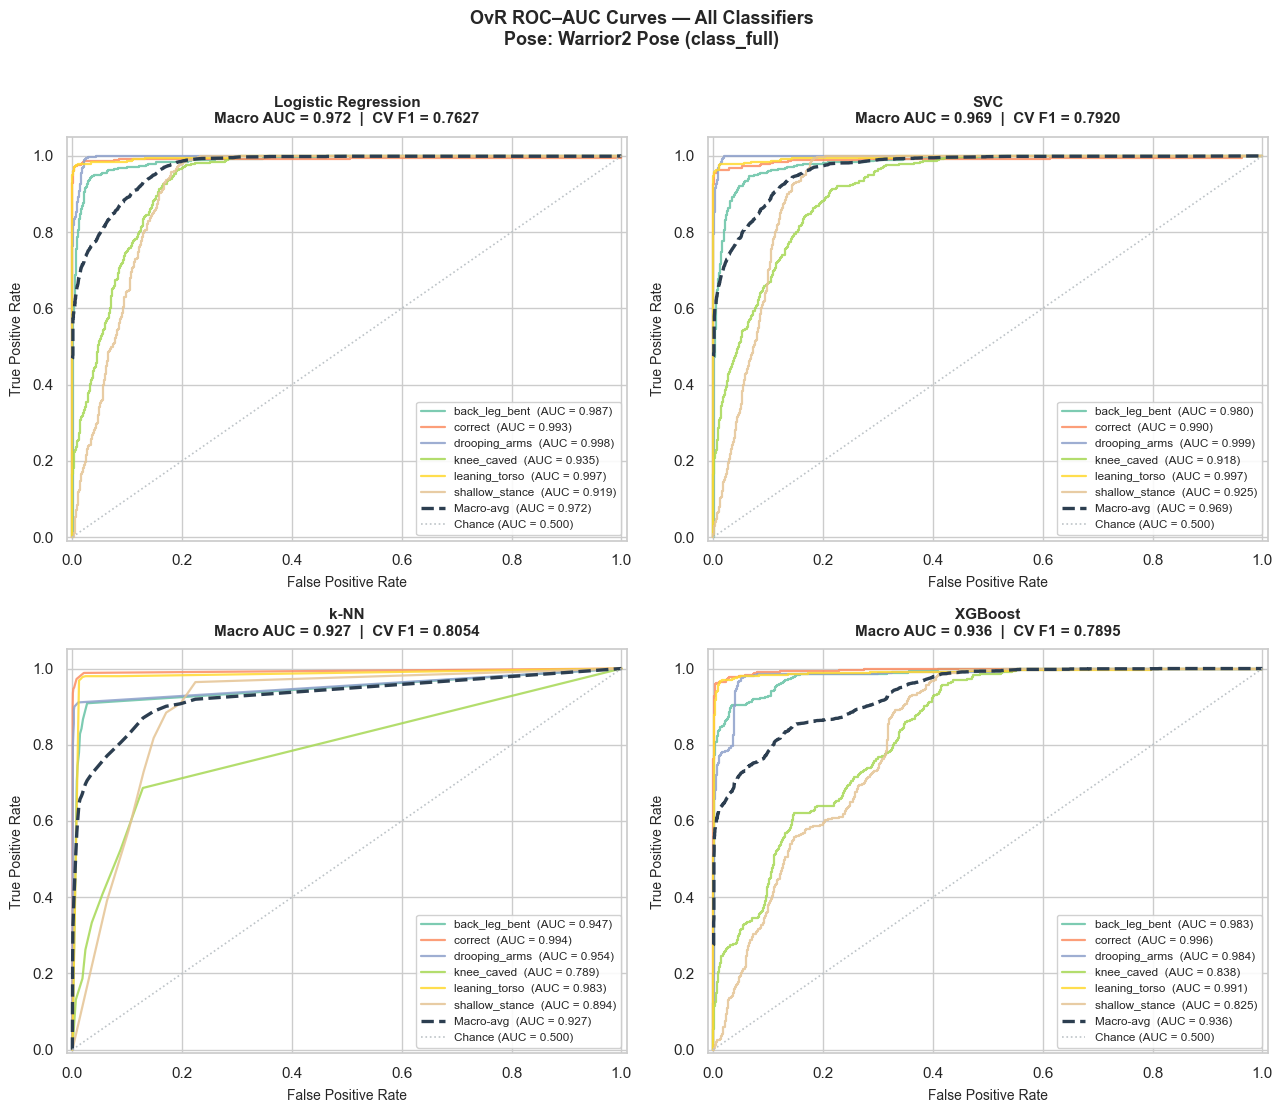

Saved ROC-AUC plot → warrior2_pose_files/images/warrior2_pose_class_full_roc_auc_curves.png


In [198]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize ground-truth once
classes      = sorted(class_map.keys())
class_labels = [class_map[c] for c in classes]
n_classes    = len(classes)
y_bin        = label_binarize(y_test, classes=classes)

formal_names = {
    "logistic_regression": "Logistic Regression",
    "svc": "SVC",
    "knn": "k-NN",
    "xgboost": "XGBoost",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
sns.set_theme(style="whitegrid")
axes_flat         = axes.flatten()
per_class_palette = plt.cm.Set2(np.linspace(0, 0.85, n_classes))

for ax_idx, result in enumerate(all_results):
    model_name    = result["model"]
    best_pipeline = best_pipelines[model_name]
    ax            = axes_flat[ax_idx]

    # Probability scores — fall back to decision_function for SVC without probability=True
    if hasattr(best_pipeline, "predict_proba"):
        y_score = best_pipeline.predict_proba(X_test)
    else:
        from sklearn.preprocessing import MinMaxScaler
        y_score = MinMaxScaler().fit_transform(
            best_pipeline.decision_function(X_test)
        )

    # Per-class ROC
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[i]        = auc(fpr[i], tpr[i])

    # Macro average
    all_fpr  = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.mean([np.interp(all_fpr, fpr[i], tpr[i]) for i in range(n_classes)], axis=0)
    macro_auc = auc(all_fpr, mean_tpr)

    # Plot per-class curves
    for i, label in enumerate(class_labels):
        ax.plot(fpr[i], tpr[i], color=per_class_palette[i], lw=1.6, alpha=0.85,
                label=f"{label}  (AUC = {roc_auc[i]:.3f})")

    # Macro average + chance diagonal
    ax.plot(all_fpr, mean_tpr, color="#2c3e50", lw=2.4, linestyle="--",
            label=f"Macro-avg  (AUC = {macro_auc:.3f})")
    ax.plot([0, 1], [0, 1], color="#bdc3c7", lw=1.2, linestyle=":",
            label="Chance (AUC = 0.500)")

    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=10, labelpad=6)
    ax.set_ylabel("True Positive Rate", fontsize=10, labelpad=6)
    ax.set_title(
        f"{formal_names.get(model_name, model_name)}\n"
        f"Macro AUC = {macro_auc:.3f}  |  CV F1 = {result['best_cv_score']:.4f}",
        fontsize=11, weight="bold", pad=10,
    )
    ax.legend(fontsize=8.5, loc="lower right", framealpha=0.9)

fig.suptitle(
    f"OvR ROC–AUC Curves — All Classifiers\n"
    f"Pose: {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})",
    fontsize=13, weight="bold", y=1.01,
)
plt.tight_layout()

roc_img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_roc_auc_curves.png"
plt.savefig(roc_img_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved ROC-AUC plot → {OUTPUT_ROOT.name}/images/{roc_img_path.name}")

## 9. Artifact Verification

In [143]:
#  Confirm all expected artifacts were written to disk ─
expected_files = []
for model_name in MODELS:
    prefix = f"{POSE_NAME}_{experiment_tag}_{model_name}"
    expected_files += [
        (DIR_MODELS    / f"{prefix}_pipeline.joblib"),
        (DIR_MODELS    / f"{prefix}_label_encoder.joblib"),
        (DIR_METADATA  / f"{prefix}_class_map.json"),
        (DIR_METADATA  / f"{prefix}_metadata.json"),
    ]

expected_files += [
    DIR_RESULTS / f"{POSE_NAME}_{experiment_tag}_experiment_results.csv",
    DIR_IMAGES  / f"{POSE_NAME}_{experiment_tag}_confusion_matrices.png",
    DIR_IMAGES  / f"{POSE_NAME}_{experiment_tag}_latency_comparison.png",
]

all_ok = True
for fpath in expected_files:
    exists  = fpath.exists()
    status  = "OK"      if exists else "MISSING"
    folder  = fpath.parent.name
    if not exists:
        all_ok = False
    print(f"  [{status}]  {folder}/{fpath.name}")

print()
print("All artifacts present." if all_ok else "WARNING: Some artifacts are missing.")

  [OK]  models/warrior2_pose_class_full_logistic_regression_pipeline.joblib
  [OK]  models/warrior2_pose_class_full_logistic_regression_label_encoder.joblib
  [OK]  metadata/warrior2_pose_class_full_logistic_regression_class_map.json
  [OK]  metadata/warrior2_pose_class_full_logistic_regression_metadata.json
  [OK]  models/warrior2_pose_class_full_svc_pipeline.joblib
  [OK]  models/warrior2_pose_class_full_svc_label_encoder.joblib
  [OK]  metadata/warrior2_pose_class_full_svc_class_map.json
  [OK]  metadata/warrior2_pose_class_full_svc_metadata.json
  [OK]  models/warrior2_pose_class_full_knn_pipeline.joblib
  [OK]  models/warrior2_pose_class_full_knn_label_encoder.joblib
  [OK]  metadata/warrior2_pose_class_full_knn_class_map.json
  [OK]  metadata/warrior2_pose_class_full_knn_metadata.json
  [OK]  models/warrior2_pose_class_full_xgboost_pipeline.joblib
  [OK]  models/warrior2_pose_class_full_xgboost_label_encoder.joblib
  [OK]  metadata/warrior2_pose_class_full_xgboost_class_map.json


## 10. Inference Smoke-Test

Loads the saved artifacts for the **best-performing model** and runs a
prediction on a single sample — exactly replicating what the real-video
inference script will do.

This verifies the full round-trip:
`raw features → load pipeline → predict → decode label`


In [ ]:
# #  Pick the best model by test F1 
# best_model_name = results_df.iloc[0]["model"]

# prefix = (
#     f"{POSE_NAME}_{experiment_tag}_{best_model_name}"
# )

# print(
#     f"Best model: {best_model_name} "
#     f"(F1={results_df.iloc[0]['test_f1_weighted']:.4f})"
# )
# print()

# #  Load artifacts from disk ─
# loaded_pipeline = joblib.load(
#     DIR_MODELS / f"{prefix}_pipeline.joblib"
# )

# loaded_encoder = joblib.load(
#     DIR_MODELS / f"{prefix}_label_encoder.joblib"
# )

# with open(
#     DIR_METADATA / f"{prefix}_class_map.json",
#     "r"
# ) as f:
#     loaded_class_map = json.load(f)

# with open(
#     DIR_METADATA / f"{prefix}_metadata.json",
#     "r"
# ) as f:
#     loaded_metadata = json.load(f)

# print("Loaded artifacts:")
# print(f"  Pipeline       : {loaded_pipeline}")
# print(f"  Label encoder  : classes = {list(loaded_encoder.classes_)}")
# print(f"  Feature columns: {loaded_metadata['feature_columns']}")
# print()

# #  Run a prediction on one test sample ─
# # In real-video inference: replace this with MediaPipe-extracted features

# sample_features = X_test[0:1]   # shape (1, n_features)

# raw_pred = loaded_pipeline.predict(sample_features)

# decoded_label = loaded_encoder.inverse_transform(raw_pred)[0]

# true_label = loaded_encoder.inverse_transform([y_test[0]])[0]

# print(f"Sample features  : {sample_features[0]}")
# print(f"Predicted (int)  : {raw_pred[0]}")
# print(f"Predicted (label): '{decoded_label}'")
# print(f"True label       : '{true_label}'")
# print()

# print(
#     "Smoke-test passed."
#     if decoded_label is not None
#     else "Smoke-test FAILED."
# )

Best model: logistic_regression (F1=0.8194)

Loaded artifacts:
  Pipeline       : Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=1000, penalty='l2',
                                    random_state=42))])
  Label encoder  : classes = ['back_leg_bent', 'correct', 'drooping_arms', 'knee_caved', 'leaning_torso', 'shallow_stance']
  Feature columns: ['back_knee_flexion_angle', 'front_knee_flexion_angle', 'spine_hip_angle', 'stance_width_normalized', 'front_knee_ankle_alignment', 'center_of_mass_torso_offset', 'wrist_height_symmetry', 'front_wrist_shoulder_vertical_offset', 'back_wrist_shoulder_vertical_offset']

Sample features  : [1.41098805e+02 1.23077615e+02 1.06112364e+02 2.37875236e+00
 1.98858125e-01 5.57330855e-02 6.20294486e-01 3.27242557e-02
 6.42898498e-01]
Predicted (int)  : 0
Predicted (label): 'back_leg_bent'
True label       : 'back_leg_bent'

Smoke-test passed.


# Comparision between 4 class and 5 class Warrior2 pose(including bent forward)

In [199]:
# Usage — load any experiment by just changing the tag
all_results_4class = load_results_from_disk(
    pose_name      = POSE_NAME,
    experiment_tag = "reduced_class",
    models         = ["logistic_regression", "svc", "knn", "xgboost"],
    DIR_METADATA   = DIR_METADATA,
)

# After 5-class run, load that too the same way
all_results_5class = load_results_from_disk(
    pose_name      = POSE_NAME,
    experiment_tag = "class_full",
    models         = ["logistic_regression", "svc", "knn", "xgboost"],
    DIR_METADATA   = DIR_METADATA,
)

# Restore confusion matrices as ndarrays
for r in all_results_4class + all_results_5class:
    r["confusion_matrix"] = np.array(r["confusion_matrix"])

Loaded 4/4 models for 'warrior2_pose' — 'reduced_class'
Loaded 4/4 models for 'warrior2_pose' — 'class_full'


## Comparison Table

In [206]:
#  Comparison Table 
formal_names = {
    "logistic_regression": "Logistic Regression",
    "svc": "SVC",
    "knn": "k-NN",
    "xgboost": "XGBoost",
}

rows = []
for tag, results in [("4-class (no bent_forward)", all_results_4class),
                     ("5-class (full)",             all_results_5class)]:
    for r in results:
        # Pull per-class recall from classification report string
        # Re-parse from stored clf string is unreliable — use conf matrix instead
        conf  = r["confusion_matrix"]
        per_class_recall = (conf.diagonal() / conf.sum(axis=1)).round(4)
        
        # class order in metadata matches class_map order
        stored_class_map = r["class_map"]   # {"0": "arms_not_dropped", ...}
        class_names_ordered = [stored_class_map[str(k)] 
                                for k in sorted(int(k) for k in stored_class_map)]
        
        recall_dict = dict(zip(class_names_ordered, per_class_recall))
        
        rows.append({
            "Experiment"              : tag,
            "Model"                   : formal_names[r["model"]],
            "CV F1"                   : r["best_cv_score"],
            "Test F1"                 : r["test_f1_weighted"],
            "Test Accuracy"           : r["test_accuracy"],
            "Recall: correct"         : recall_dict.get("correct",          None),
            "Recall: drooping_arms"   : recall_dict.get("drooping_arms",  None),
            "Recall: knee_caved"     : recall_dict.get("knee_caved",       None),
            "Recall: leaning_torso"     : recall_dict.get("leaning_torso",       None),
            "Recall: shallow_stance"    : recall_dict.get("shallow_stance",      None),
            "Recall: back_leg_bent"    : recall_dict.get("back_leg_bent",      None),
        })

df_comparison = pd.DataFrame(rows)

# Save
csv_path = DIR_RESULTS / f"{POSE_NAME}_4class_vs_5class_comparison.csv"
df_comparison.to_csv(csv_path, index=False)

print(df_comparison.to_string(index=False))

               Experiment               Model  CV F1  Test F1  Test Accuracy  Recall: correct  Recall: drooping_arms  Recall: knee_caved  Recall: leaning_torso  Recall: shallow_stance  Recall: back_leg_bent
4-class (no bent_forward) Logistic Regression 0.8891   0.9476         0.9481           0.9588                 0.9911              0.8400                 0.9844                     NaN                 0.9667
4-class (no bent_forward)                 SVC 0.9131   0.9217         0.9217           0.9863                 0.9933              0.8267                 0.9822                     NaN                 0.8222
4-class (no bent_forward)                k-NN 0.8995   0.9395         0.9396           0.9703                 0.9778              0.8844                 0.9800                     NaN                 0.8867
4-class (no bent_forward)             XGBoost 0.9014   0.9512         0.9508           0.9725                 0.9778              0.9133                 0.9733             

## Visual Comparison

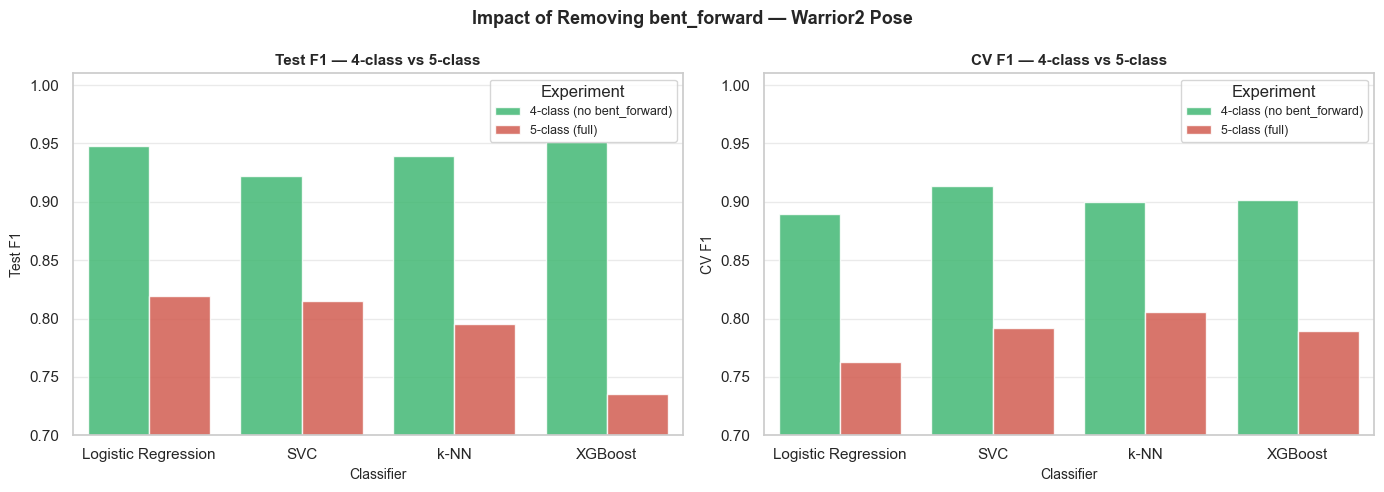

In [207]:
#  Visual Comparison — Test F1 & CV F1 side by side 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

for ax, metric in zip(axes, ["Test F1", "CV F1"]):
    sns.barplot(
        data    = df_comparison,
        x       = "Model",
        y       = metric,
        hue     = "Experiment",
        palette = ["#2ecc71", "#e74c3c"],
        alpha   = 0.85,
        ax      = ax,
    )
    ax.set_title(f"{metric} — 4-class vs 5-class", fontsize=11, weight="bold")
    ax.set_ylabel(metric, fontsize=10)
    ax.set_xlabel("Classifier", fontsize=10)
    ax.set_ylim(0.70, 1.01)
    ax.legend(title="Experiment", fontsize=9)
    ax.grid(axis="y", alpha=0.4)

plt.suptitle(
    f"Impact of Removing bent_forward — {POSE_NAME.replace('_',' ').title()}",
    fontsize=13, weight="bold"
)
plt.tight_layout()
plt.savefig(DIR_IMAGES / f"{POSE_NAME}_4vs5class_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Per-class Recall Heatmap

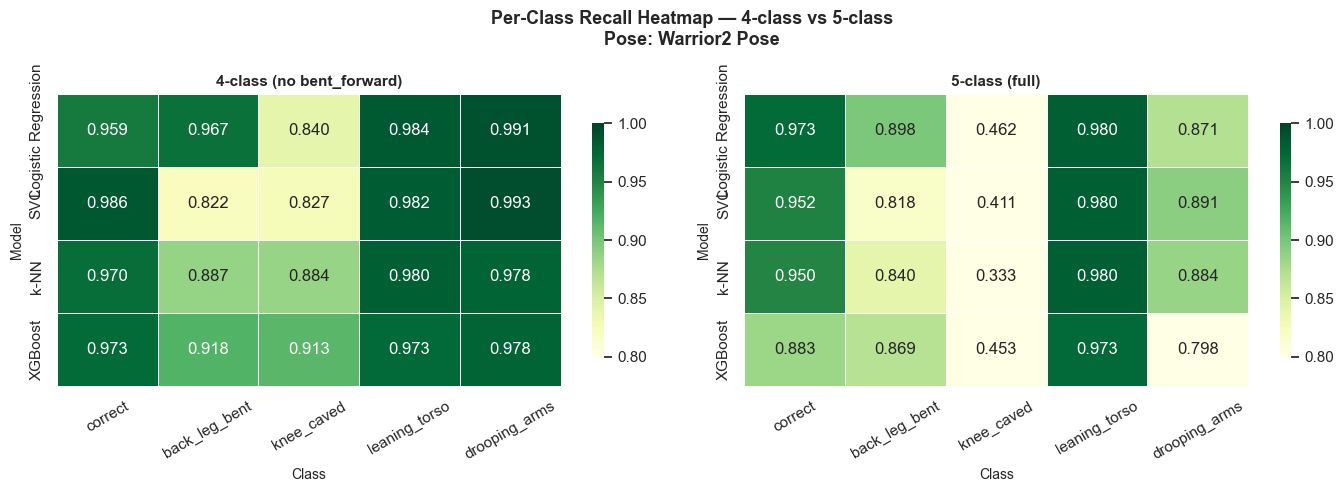

In [210]:
#  Per-class Recall Heatmap — the most informative plot 
# This directly tests your hypothesis: does removing bent_forward
# improve 'correct' recall?

recall_cols = ["Recall: correct", "Recall: back_leg_bent",
               "Recall: knee_caved", "Recall: leaning_torso", "Recall: drooping_arms"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (tag, results) in zip(axes, [("4-class (no bent_forward)", all_results_4class),
                                      ("5-class (full)",            all_results_5class)]):
    rows_tag = df_comparison[df_comparison["Experiment"] == tag]
    heat_data = rows_tag.set_index("Model")[recall_cols]
    heat_data.columns = [c.replace("Recall: ", "") for c in heat_data.columns]

    sns.heatmap(
        heat_data.astype(float),
        ax          = ax,
        annot       = True,
        fmt         = ".3f",
        cmap        = "YlGn",
        vmin        = 0.80,
        vmax        = 1.00,
        linewidths  = 0.5,
        cbar_kws    = {"shrink": 0.8},
    )
    ax.set_title(tag, fontsize=11, weight="bold")
    ax.set_xlabel("Class", fontsize=10)
    ax.set_ylabel("Model", fontsize=10)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle(
    f"Per-Class Recall Heatmap — 4-class vs 5-class\n"
    f"Pose: {POSE_NAME.replace('_',' ').title()}",
    fontsize=13, weight="bold"
)
plt.tight_layout()
plt.savefig(DIR_IMAGES / f"{POSE_NAME}_5vs6class_recall_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Delta Table

In [ ]:
#  Delta Table — quantify the exact impact of removing bent_forward 
delta_rows = []
for r4, r5 in zip(
    df_comparison[df_comparison["Experiment"] == "4-class (no bent_forward)"].itertuples(),
    df_comparison[df_comparison["Experiment"] == "5-class (full)"].itertuples(),
):
    delta_rows.append({
        "Model"                        : r4.Model,
        "ΔTest F1  (4-5)"              : round(r4._4 - r5._4, 4),   # positive = 4class better
        "ΔCV F1   (4-5)"               : round(r4._3 - r5._3, 4),
        "ΔRecall: correct (4-5)"       : round((r4._6 or 0) - (r5._6 or 0), 4),
        "ΔRecall: arms_not_dropped(4-5)": round((r4._7 or 0) - (r5._7 or 0), 4),
    })

df_delta = pd.DataFrame(delta_rows)
print("Delta Table (positive = 5-class is better, negative = 6-class is better)")
print()
print(df_delta.to_string(index=False))

df_delta.to_csv(DIR_RESULTS / f"{POSE_NAME}_5vs6class_delta.csv", index=False)

Delta Table (positive = 5-class is better, negative = 6-class is better)

Empty DataFrame
Columns: []
Index: []
